In [1]:
# AdEase provides ad placement services, the data that they have is views for a Wikipedia page
# As a data scientist your goal is to forecast the number of views on the Wikipedia page so that
# perfect page can be suggested to the client to place Ads

In [49]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

from statsmodels.tsa.arima.model import ARIMA

In [5]:
# Read the file
df = pd.read_csv('train_1.csv')
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [9]:
# Dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB


In [11]:
# Nulls
df.isna().sum()

Page              0
2015-07-01    20740
2015-07-02    20816
2015-07-03    20544
2015-07-04    20654
              ...  
2016-12-27     3701
2016-12-28     3822
2016-12-29     3826
2016-12-30     3635
2016-12-31     3465
Length: 551, dtype: int64

In [13]:
# Duplicates
df.duplicated().value_counts()

False    145063
Name: count, dtype: int64

In [15]:
# Read the campaign file
exog_en = pd.read_csv('Exog_Campaign_eng')
exog_en.head()

,Exog
0,0
1,0
2,0
3,0
4,0


In [17]:
exog_en.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exog    550 non-null    int64
dtypes: int64(1)
memory usage: 4.4 KB


In [19]:
exog_en['Exog'].value_counts()

Exog
0    496
1     54
Name: count, dtype: int64

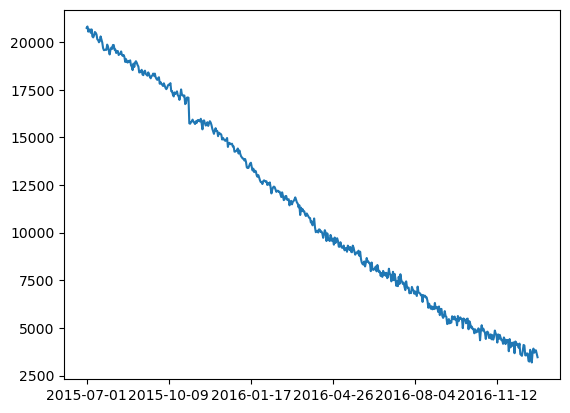

In [21]:
# EDA
date_col = df.columns[1:]
df[date_col].isna().sum().plot()
plt.show()

In [25]:
# Fill na with 0
df[date_col] = df.loc[:, date_col].fillna(0)

In [27]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [29]:
# Extract language from the page name
def extract_lang(page):
    pattern = r'(.{0,})_(.{2}).wikipedia.org_'
    result = re.findall(pattern, page)
    if len(result) == 1:
        return result[0][1]
    else:
        return 'un'
df['language'] = df['Page'].apply(extract_lang)
df['language'].unique()

/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_2241/1265494649.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['language'] = df['Page'].apply(extract_lang)


array(['zh', 'fr', 'en', 'un', 'ru', 'de', 'ja', 'es'], dtype=object)

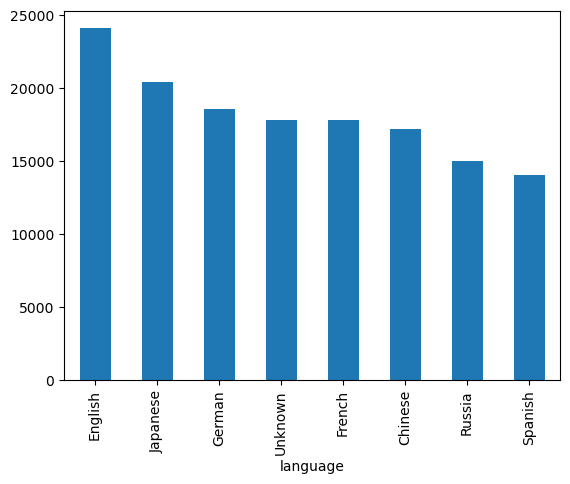

In [31]:
lang_mapper = {
    'zh': 'Chinese',
    'fr': 'French',
    'en': 'English',
    'un': 'Unknown',
    'ru': 'Russia',
    'de': 'German',
    'ja': 'Japanese',
    'es': 'Spanish'
}
df['language'] = df['language'].map(lang_mapper)
df['language'].value_counts().plot(kind='bar')
plt.show()

In [33]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,language
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0,Chinese
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0,Chinese
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0,Chinese
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0,Chinese
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0,Chinese


In [37]:
# Transform the data
df_agg = df.drop(columns=['Page']).groupby('language').mean().T.reset_index()
df_agg['index'] = pd.to_datetime(df_agg['index'])
df_agg = df_agg.set_index('index')
df_agg.head()

language,Chinese,English,French,German,Japanese,Russia,Spanish,Unknown
index,,,,,,,,
2015-07-01,240.582042,3513.862203,475.150994,714.968405,580.647056,629.999601,1085.972919,83.479922
2015-07-02,240.941958,3502.511407,478.202000,705.229741,666.672801,640.902876,1037.814557,87.471857
2015-07-03,239.344071,3325.357889,459.837659,676.877231,602.289805,594.026295,954.412680,82.680538
2015-07-04,241.653491,3462.054256,491.508932,621.145145,756.509177,558.728132,896.050750,70.572557
2015-07-05,257.779674,3575.520035,482.557746,722.076185,725.720914,595.029157,974.508210,78.214562


In [39]:
# Time series analysis
ts_english = df_agg['English']
ts_english.head()

index
2015-07-01    3513.862203
2015-07-02    3502.511407
2015-07-03    3325.357889
2015-07-04    3462.054256
2015-07-05    3575.520035
Name: English, dtype: float64

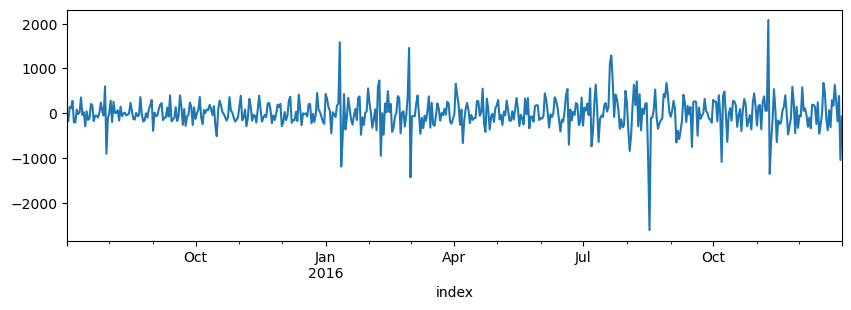

In [41]:
# De trending and De-seasoning
ts_english.diff(1).dropna().plot(figsize=(10,3))
plt.show()

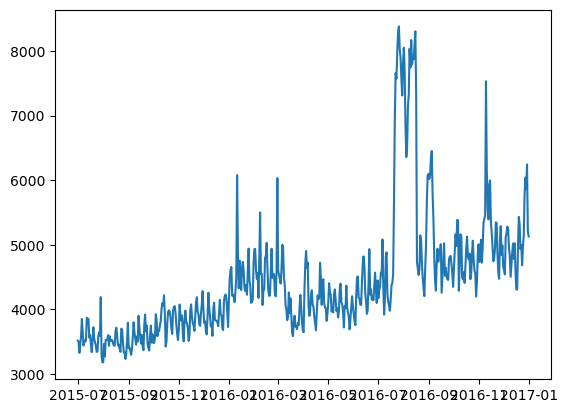

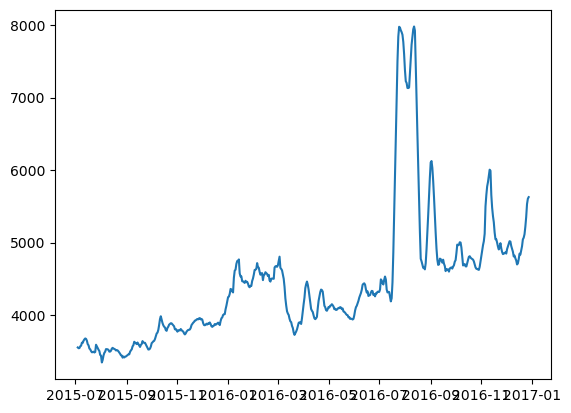

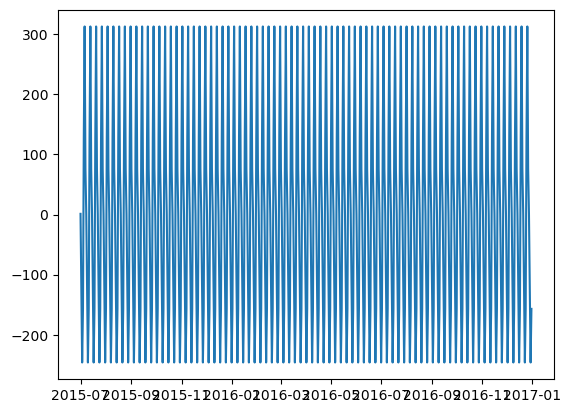

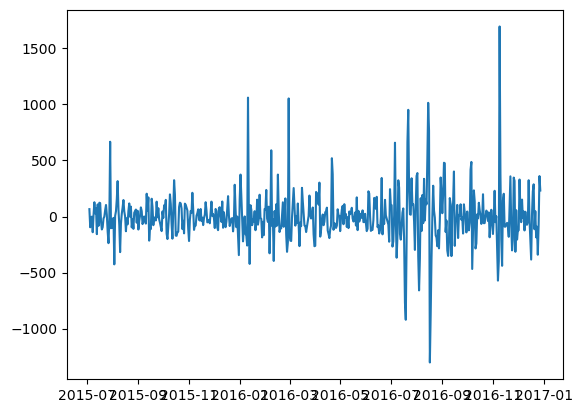

In [47]:
# Auto decomposition
decom = seasonal_decompose(ts_english)
ts_english_trend = decom.trend
ts_english_seas = decom.seasonal
ts_english_res = decom.resid
plt.plot(ts_english, label='actual')
plt.show()
plt.plot(ts_english_trend, label='trend')
plt.show()
plt.plot(ts_english_seas, label='seasonal')
plt.show()
plt.plot(ts_english_res, label='residual')
plt.show()

In [65]:
# Build models ARIMA, SARIMA
def model_performance(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)**0.5
    mape = mean_absolute_percentage_error(actual, predicted)
    print(mae)
    print(mse)
    print(mape)
    return mae, mse, mape

In [67]:
TS = ts_english.copy(deep=True)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


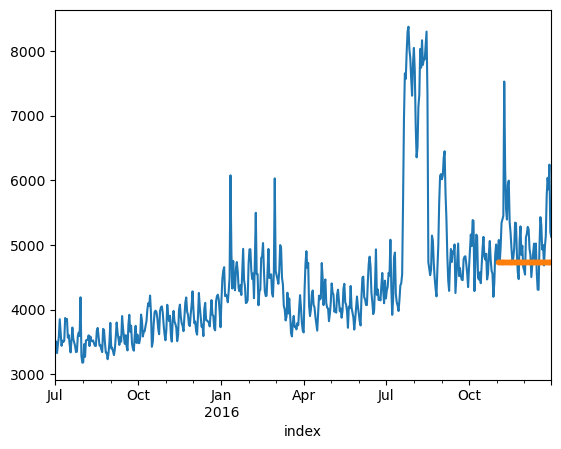

477.63645677783336
672.7776211857341
0.08620375577666274


(477.63645677783336, 672.7776211857341, 0.08620375577666274)

In [69]:
n_forecast = 60
model = ARIMA(TS[:-n_forecast], order=(0,1,0))
model = model.fit()
predicted = model.forecast(steps=n_forecase, alpha=0.05)
TS.plot(label='actual')
predicted.plot(label='forecast', linestyle='dashed', marker='.')
plt.show()
model_performance(TS.values[-n_forecast:], predicted.values)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.05859D+00    |proj g|=  6.41979D-02

At iterate    5    f=  7.02947D+00    |proj g|=  3.37090D-03

At iterate   10    f=  6.98944D+00    |proj g|=  3.72190D-02

At iterate   15    f=  6.96032D+00    |proj g|=  3.82955D-04
  ys=-4.480E-02  -gs= 2.093E-03 BFGS update SKIPPED

At iterate   20    f=  6.94331D+00    |proj g|=  7.97060D-02

At iterate   25    f=  6.93868D+00    |proj g|=  1.11039D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Proj

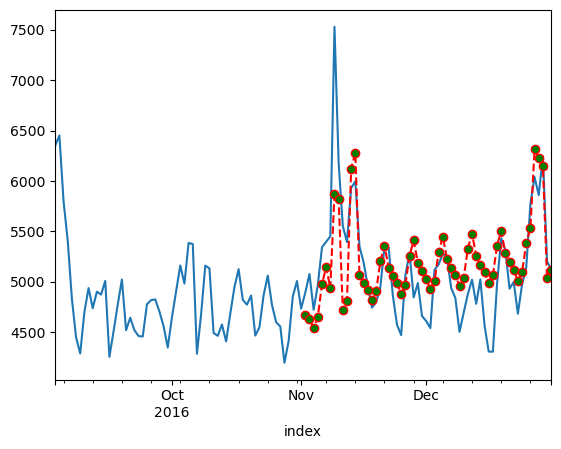

306.41571065667057
399.01516583014876
0.059677452639862


(306.41571065667057, 399.01516583014876, 0.059677452639862)

In [75]:
# SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX
exog = exog_en['Exog'].to_numpy()
p,d,q,P,D,Q,s = 1,1,1,1,1,1,7
n_forecast = 60
model = SARIMAX(TS[:-n_forecast], order=(p,d,q), seasonal_order=(P, D, Q, s), exog=exog[:-n_forecast], initialization='approximate_diffuse')
model_fit = model.fit()
model_forecast = model_fit.forecast(n_forecast, dynamic=True, exog=pd.DataFrame(exog[-n_forecast:]))
TS[-120:].plot(label='actual')
model_forecast[-120:].plot(label='forecast', color='red', linestyle='dashed', marker='o', markerfacecolor='green')
plt.show()
model_performance(TS.values[-n_forecast:], model_forecast.values)

In [81]:
# Run Facebook Prophet
TS = ts_english.copy(deep=True).reset_index()
TS = TS[['index', 'English']]
TS.columns = ['ds', 'y']
TS['ds'] = pd.to_datetime(TS['ds'])
exog = exog_en['Exog']
TS['exog'] = exog.values
TS.head()

,ds,y,exog
0,2015-07-01,3513.862203,0
1,2015-07-02,3502.511407,0
2,2015-07-03,3325.357889,0
3,2015-07-04,3462.054256,0
4,2015-07-05,3575.520035,0


In [85]:
from prophet import Prophet
prophet_model = Prophet(interval_width=0.95,
                        daily_seasonality=False,
                        weekly_seasonality=True,
                        yearly_seasonality=False)
prophet_model.add_regressor('exog')
n_forecast = 60
prophet_model.fit(TS)
future_dates = prophet_model.make_future_dataframe(periods=0)
future_dates['exog'] = TS['exog']
forecast = prophet_model.predict(future_dates)

TS['yhat'] = forecast['yhat']
TS['yhat_upper'] = forecast['yhat_upper']
TS['yhat_lower'] = forecast['yhat_lower']

model_performance(TS['y'], TS['yhat'])

18:57:16 - cmdstanpy - INFO - Chain [1] start processing
18:57:16 - cmdstanpy - INFO - Chain [1] done processing


287.81923493590375
442.00878475120703
0.06017269721742727


(287.81923493590375, 442.00878475120703, 0.06017269721742727)

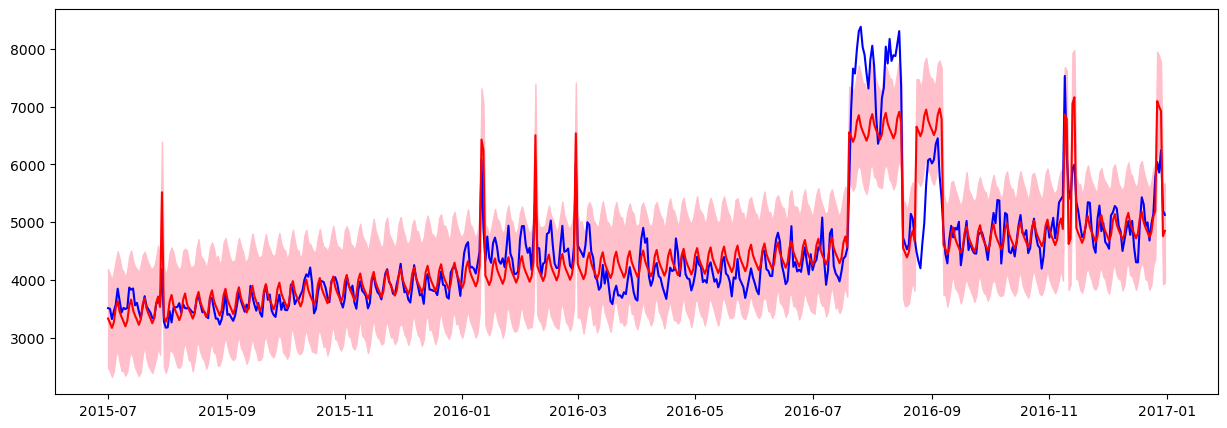

In [89]:
plt.figure(figsize=(15, 5))
plt.plot(TS['ds'], TS['y'], label='actual', color='blue')
plt.plot(TS['ds'], TS['yhat'], label='predicted', color='red')
plt.fill_between(TS['ds'], TS['yhat_lower'], TS['yhat_upper'], color='pink')